# Experiment 1
In this notebook, we first create a toy dataset to test our CRP function and see how a constant rebalanced portfolio can benefit from daily rebalancing. And then we will see the practical performance of the Universal Portfolio algorithm on real stock data.

We use the `crp_func` in `src.jl`, using a toy dataset. 

And then use `uni_port_func` function. The dataset we used is `prices_4stocks.csv`, the time horizon is one-year period.

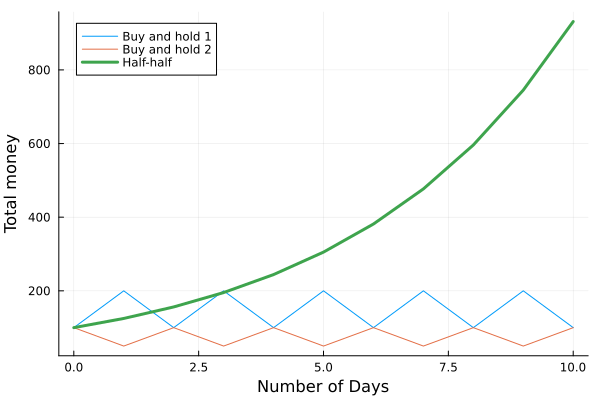

In [5]:
using Plots  
using CSV
using DataFrames
using Plots
using LinearAlgebra
using Revise
include("../src/src.jl")

# We will create a price matrix with T + 1 rows and 2 columns
T = 10
prices= ones(Float64,T + 1,2) #Initialization

#The two assets move in opposite directions ,if t is even, 
#Asset 1 doubles and Asset 2 halves, vice versa.
for t in 2:(T + 1)
    if iseven(t)
        prices[t,1]= prices[t-1,1]*2.0 #double
        prices[t,2]= prices[t-1,2]*0.5 #half
    else
        prices[t,1]= prices[t-1,1]*0.5
        prices[t,2]= prices[t-1,2]*2.0
    end
end

init_money = 100.0
wealth_1= init_money.*crp_func(prices,[1.0, 0.0])# Wealth trajectory if invest all money in Asset 1.
wealth_2= init_money.*crp_func(prices,[0.0, 1.0])# Invest all money in Asset 2
wealth_half= init_money.*crp_func(prices,[0.5, 0.5]) # Half Half

p=plot(0:T,wealth_1,label = "Buy and hold 1",xlabel= "Number of Days",ylabel = "Total money")
plot!(0:T,wealth_2, label = "Buy and hold 2")
plot!(0:T,wealth_half,label ="Half-half",linewidth = 3)

savefig(p, "wealth_trajectories.png")
display(p)

In [6]:
price_df= CSV.read("../dataset/prices_4stocks.csv", DataFrame)
println(size(price_df))
println(first(price_df, 5))
println(names(price_df))

(250, 5)
5×5 DataFrame
 Row │ timestamp            AAPL     TSLA     KO       WMT     
     │ DateTime             Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2025-01-02T14:30:00   243.85   379.28    61.84    90.0
   2 │ 2025-01-03T14:30:00   243.36   410.44    61.75    90.78
   3 │ 2025-01-06T14:30:00   245.0    411.05    60.81    91.43
   4 │ 2025-01-07T14:30:00   242.21   394.36    60.84    90.81
   5 │ 2025-01-08T14:30:00   242.7    394.94    61.71    91.8
["timestamp", "AAPL", "TSLA", "KO", "WMT"]


Stock columns: ["AAPL", "TSLA", "KO", "WMT"]
Price matrix size: (250, 4)


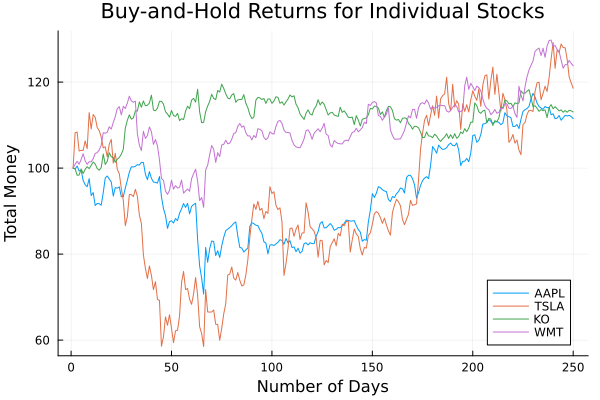

"c:\\Users\\Odysseus\\GR6104_homework\\final_proj\\notebooks\\Buy_and_hold_returns for Individual Stocks.png"

In [7]:
init_money= 100.0
stock_cols= names(price_df)[2:end]
prices= Matrix{Float64}(select(price_df,stock_cols)) # we store the stock_cols as prices
println("Stock columns: ", stock_cols)
println("Price matrix size: ", size(prices))
# for each stock we compute wealth trajectory for buy and hold strategy
buy_hold= init_money.*(prices./reshape(prices[1,:],1,:))
p1= plot(title="Buy-and-Hold Returns for Individual Stocks",xlabel="Number of Days",ylabel= "Total Money")
for i in 1:length(stock_cols) # we plot buy-and-hold wealth trajectory for each stock
    plot!(p1,buy_hold[:, i],label = stock_cols[i])
end
display(p1)
savefig(p1,"Buy_and_hold_returns for Individual Stocks")

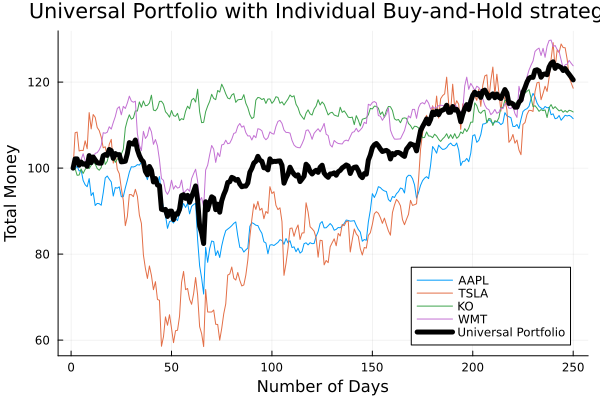

"c:\\Users\\Odysseus\\GR6104_homework\\final_proj\\notebooks\\UP with Individual strategy.png"

In [8]:
# We set the step size eta as 0.1 and use our 'uni_port_func' function
eta= 0.1
# up_wealth measures how the Universal Portfolio's money grows over time
# S_grid means the wealth of each candidate CRP portfolio on simplex grid
up_wealth,b_weights,S_grid= uni_port_func(prices,eta)
up_money= init_money .* up_wealth

p2= plot(title= "Universal Portfolio with Individual Buy-and-Hold strategy",xlabel= "Number of Days",
ylabel= "Total Money")
for i in 1:length(stock_cols)
    plot!(p2,buy_hold[:, i], label=stock_cols[i])
end
plot!(p2,up_money,label="Universal Portfolio",linewidth = 5,color = :black)
display(p2)
savefig(p2,"UP with Individual strategy")

We could observe that the Universal Portfolio does not simply follow one stock.

It combines different CRPs and produces a smoother wealth line than the individual stocks. It seems to be more robust against risk.

